# Week 7 — Robot Sensor Anomaly Detection Benchmark

## Objective

This notebook evaluates anomaly detection methods on synthetic robot sensor data.

Five controlled fault types are injected into normal robot operation:

1. Motor stall
2. Proximity sensor drift
3. Battery degradation
4. IMU axis failure
5. RSSI disruption

Four anomaly detection approaches are benchmarked:

1. Frequency-band energy threshold
2. Isolation Forest
3. One-Class SVM
4. Supervised binary classifier

Performance is evaluated across 10 random seeds using precision, recall, F1 score, and AUROC. The two best-performing methods are further compared using a paired Wilcoxon signed-rank test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from scipy.stats import wilcoxon

RANDOM_SEEDS = list(range(10))

np.random.seed(42)

## 1. Load Week 2 Synthetic Robot Sensor Data

The synthetic robot sensor datasets generated in Week 2 are loaded below.
Both the 5-minute aggregated dataset and the high-frequency sensor dataset
are inspected before constructing the anomaly injection pipeline.

In [6]:
# Data paths

data_5min_path = "../data/robot_sensor_5min.csv"
data_highfreq_path = "../data/robot_sensor_highfreq.csv"

# Load datasets
df_5min = pd.read_csv(data_5min_path)
df_highfreq = pd.read_csv(data_highfreq_path)

print("5-minute dataset shape:", df_5min.shape)
print("High-frequency dataset shape:", df_highfreq.shape)

5-minute dataset shape: (120960, 12)
High-frequency dataset shape: (48000, 8)


In [7]:
print("=== 5-minute dataset ===")
display(df_5min.head())

print("\nColumns:")
print(df_5min.columns.tolist())

=== 5-minute dataset ===


,timestamp,robot_id,mode,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success,imu_magnitude
0,2026-08-10 00:00:00,R01,PATROL,0.181560,-0.022685,9.765057,1.806318,2.234491,-55.888431,93.100778,0,9.766771
1,2026-08-10 00:05:00,R01,PATROL,0.003813,-0.122254,9.707094,2.288695,4.781291,-61.387078,93.089032,1,9.707865
2,2026-08-10 00:10:00,R01,PATROL,0.114086,0.233848,9.832063,2.383943,5.134641,-56.865756,93.065962,1,9.835505
3,2026-08-10 00:15:00,R01,PATROL,0.412985,0.196385,9.728399,2.340912,2.719345,-61.019880,93.026576,1,9.739142
4,2026-08-10 00:20:00,R01,PATROL,0.264022,0.340855,10.063573,2.323048,2.675605,-55.376955,93.016117,1,10.072805



Columns:
['timestamp', 'robot_id', 'mode', 'accel_x', 'accel_y', 'accel_z', 'motor_current', 'proximity', 'rssi', 'battery_soc', 'task_success', 'imu_magnitude']


In [8]:
print("=== High-frequency dataset ===")
display(df_highfreq.head())

print("\nColumns:")
print(df_highfreq.columns.tolist())

=== High-frequency dataset ===


,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0



Columns:
['time', 'mode', 'motor_current', 'accel_x', 'accel_y', 'accel_z', 'imu_magnitude', 'window_id']


In [9]:
print("=== 5-minute dataset info ===")
df_5min.info()

print("\n=== Missing values ===")
print(df_5min.isna().sum())

=== 5-minute dataset info ===
<class 'pandas.DataFrame'>
RangeIndex: 120960 entries, 0 to 120959
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   timestamp      120960 non-null  str    
 1   robot_id       120960 non-null  str    
 2   mode           120960 non-null  str    
 3   accel_x        120960 non-null  float64
 4   accel_y        120960 non-null  float64
 5   accel_z        120960 non-null  float64
 6   motor_current  120960 non-null  float64
 7   proximity      120960 non-null  float64
 8   rssi           120960 non-null  float64
 9   battery_soc    120960 non-null  float64
 10  task_success   120960 non-null  int64  
 11  imu_magnitude  120960 non-null  float64
dtypes: float64(8), int64(1), str(3)
memory usage: 11.1 MB

=== Missing values ===
timestamp        0
robot_id         0
mode             0
accel_x          0
accel_y          0
accel_z          0
motor_current    0
proximity        0
rssi 

In [10]:
print("=== High-frequency dataset info ===")
df_highfreq.info()

print("\n=== Missing values ===")
print(df_highfreq.isna().sum())

=== High-frequency dataset info ===
<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           48000 non-null  float64
 1   mode           48000 non-null  str    
 2   motor_current  48000 non-null  float64
 3   accel_x        48000 non-null  float64
 4   accel_y        48000 non-null  float64
 5   accel_z        48000 non-null  float64
 6   imu_magnitude  48000 non-null  float64
 7   window_id      48000 non-null  int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 2.9 MB

=== Missing values ===
time             0
mode             0
motor_current    0
accel_x          0
accel_y          0
accel_z          0
imu_magnitude    0
window_id        0
dtype: int64


## 2. Extend the Synthetic Dataset for Fault Injection

The Week 2 synthetic telemetry did not include a velocity channel. Because the
Week 7 motor-stall definition requires a simultaneous motor-current spike and
velocity drop, a synthetic velocity signal is added while preserving the
original Week 2 datasets.

The velocity profile is generated according to the robot operating mode and
is used only for the Week 7 anomaly-injection benchmark.

In [11]:
# Create a Week 7 working copy
df_w7 = df_5min.copy()

# Reproducible random generator
rng = np.random.default_rng(42)

# Initialize velocity column
df_w7["velocity"] = 0.0

# Mode-specific synthetic velocity profiles
velocity_params = {
    "PATROL":   (0.80, 0.12),
    "ALERT":    (1.10, 0.18),
    "CHARGING": (0.02, 0.01),
    "FAULT":    (0.35, 0.20),
}

for mode, (mean_velocity, std_velocity) in velocity_params.items():
    mask = df_w7["mode"] == mode
    n = mask.sum()

    df_w7.loc[mask, "velocity"] = rng.normal(
        loc=mean_velocity,
        scale=std_velocity,
        size=n
    )

# Velocity cannot be negative
df_w7["velocity"] = df_w7["velocity"].clip(lower=0)

df_w7[["mode", "motor_current", "velocity"]].head(10)

,mode,motor_current,velocity
0,PATROL,1.806318,0.836566
1,PATROL,2.288695,0.675202
2,PATROL,2.383943,0.890054
3,PATROL,2.340912,0.912868
4,PATROL,2.323048,0.565876
5,PATROL,2.578081,0.643738
6,PATROL,2.305173,0.815341
7,PATROL,2.066452,0.762051
8,PATROL,1.659372,0.797984
9,PATROL,1.973321,0.697635


In [12]:
velocity_summary = (
    df_w7.groupby("mode")
    .agg(
        mean_velocity=("velocity", "mean"),
        std_velocity=("velocity", "std"),
        mean_motor_current=("motor_current", "mean"),
        sample_count=("velocity", "size")
    )
    .round(3)
)

display(velocity_summary)

,mean_velocity,std_velocity,mean_motor_current,sample_count
mode,,,,
ALERT,1.096,0.182,3.306,5244
CHARGING,0.020,0.010,0.200,17102
FAULT,0.357,0.193,4.502,2156
PATROL,0.800,0.120,2.001,96458


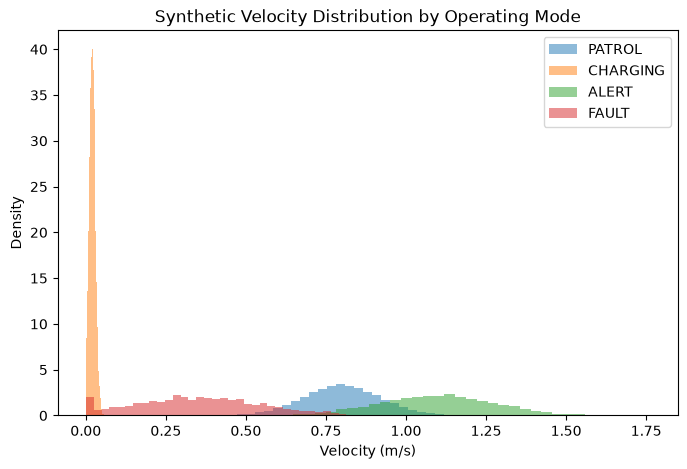

In [13]:
plt.figure(figsize=(8, 5))

for mode in df_w7["mode"].unique():
    subset = df_w7.loc[df_w7["mode"] == mode, "velocity"]

    plt.hist(
        subset,
        bins=40,
        alpha=0.5,
        label=mode,
        density=True
    )

plt.xlabel("Velocity (m/s)")
plt.ylabel("Density")
plt.title("Synthetic Velocity Distribution by Operating Mode")
plt.legend()
plt.show()

## 3. Define the Normal Operational Baseline

Controlled Week 7 anomalies should be evaluated against normal robot
operation. Therefore, the original Week 2 `FAULT` mode is excluded from
the normal baseline before injecting the five controlled fault types.

In [14]:
normal_df = (
    df_w7[df_w7["mode"] != "FAULT"]
    .copy()
    .reset_index(drop=True)
)

print("Original Week 7 working dataset:", df_w7.shape)
print("Normal baseline dataset:", normal_df.shape)

print("\nNormal baseline modes:")
print(normal_df["mode"].value_counts())

Original Week 7 working dataset: (120960, 13)
Normal baseline dataset: (118804, 13)

Normal baseline modes:
mode
PATROL      96458
CHARGING    17102
ALERT        5244
Name: count, dtype: int64


## 4. Controlled Fault Injection

### 4.1 Motor Stall

A motor stall is simulated as a sudden increase in motor current accompanied
by a sharp decrease in robot velocity. Motor stalls are injected only during
active operating modes (`PATROL` and `ALERT`), since the robot is already
nearly stationary during `CHARGING`.

The injected samples are labeled as anomalies to provide ground-truth labels
for evaluating the anomaly detection methods.

In [15]:
def inject_motor_stall(
    df,
    fault_fraction=0.05,
    seed=42
):
    """
    Inject synthetic motor-stall anomalies.

    A motor stall is represented by:
    - a sudden increase in motor current
    - a sharp decrease in velocity

    Faults are injected only during active modes
    (PATROL and ALERT).
    """

    data = df.copy()
    rng = np.random.default_rng(seed)

    # Ground-truth labels
    data["is_anomaly"] = 0
    data["fault_type"] = "normal"

    # Only inject stalls while the robot is moving
    eligible_mask = data["mode"].isin(["PATROL", "ALERT"])
    eligible_idx = data.index[eligible_mask].to_numpy()

    # Select anomaly samples
    n_faults = int(len(eligible_idx) * fault_fraction)

    fault_idx = rng.choice(
        eligible_idx,
        size=n_faults,
        replace=False
    )

    # Current spike: approximately 2.5–4× normal current
    current_multiplier = rng.uniform(
        2.5,
        4.0,
        size=n_faults
    )

    data.loc[fault_idx, "motor_current"] *= current_multiplier

    # Velocity drops to approximately 0–10% of normal
    velocity_multiplier = rng.uniform(
        0.0,
        0.1,
        size=n_faults
    )

    data.loc[fault_idx, "velocity"] *= velocity_multiplier

    # Ground-truth anomaly labels
    data.loc[fault_idx, "is_anomaly"] = 1
    data.loc[fault_idx, "fault_type"] = "motor_stall"

    return data

In [16]:
motor_stall_df = inject_motor_stall(
    normal_df,
    fault_fraction=0.05,
    seed=42
)

print(motor_stall_df["fault_type"].value_counts())

fault_type
normal         113719
motor_stall      5085
Name: count, dtype: int64


In [17]:
motor_stall_summary = (
    motor_stall_df
    .groupby("fault_type")[
        ["motor_current", "velocity"]
    ]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

display(motor_stall_summary)

motor_current                       velocity                  
                     mean    std    min     max     mean    std  min   max
fault_type                                                                
motor_stall         6.678  1.711  3.168  17.075    0.041  0.025  0.0  0.13
normal              1.788  0.786 -0.001   5.258    0.695  0.312  0.0  1.76

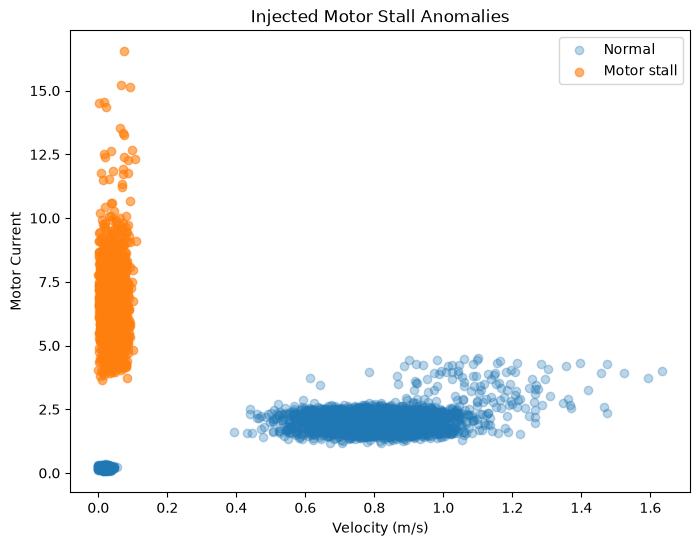

In [18]:
plt.figure(figsize=(8, 6))

normal_sample = motor_stall_df[
    motor_stall_df["is_anomaly"] == 0
].sample(
    n=3000,
    random_state=42
)

fault_sample = motor_stall_df[
    motor_stall_df["is_anomaly"] == 1
].sample(
    n=min(
        1000,
        (motor_stall_df["is_anomaly"] == 1).sum()
    ),
    random_state=42
)

plt.scatter(
    normal_sample["velocity"],
    normal_sample["motor_current"],
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    fault_sample["velocity"],
    fault_sample["motor_current"],
    alpha=0.6,
    label="Motor stall"
)

plt.xlabel("Velocity (m/s)")
plt.ylabel("Motor Current")
plt.title("Injected Motor Stall Anomalies")
plt.legend()
plt.show()